计算 SVD（矩阵大小 1024x1024）...


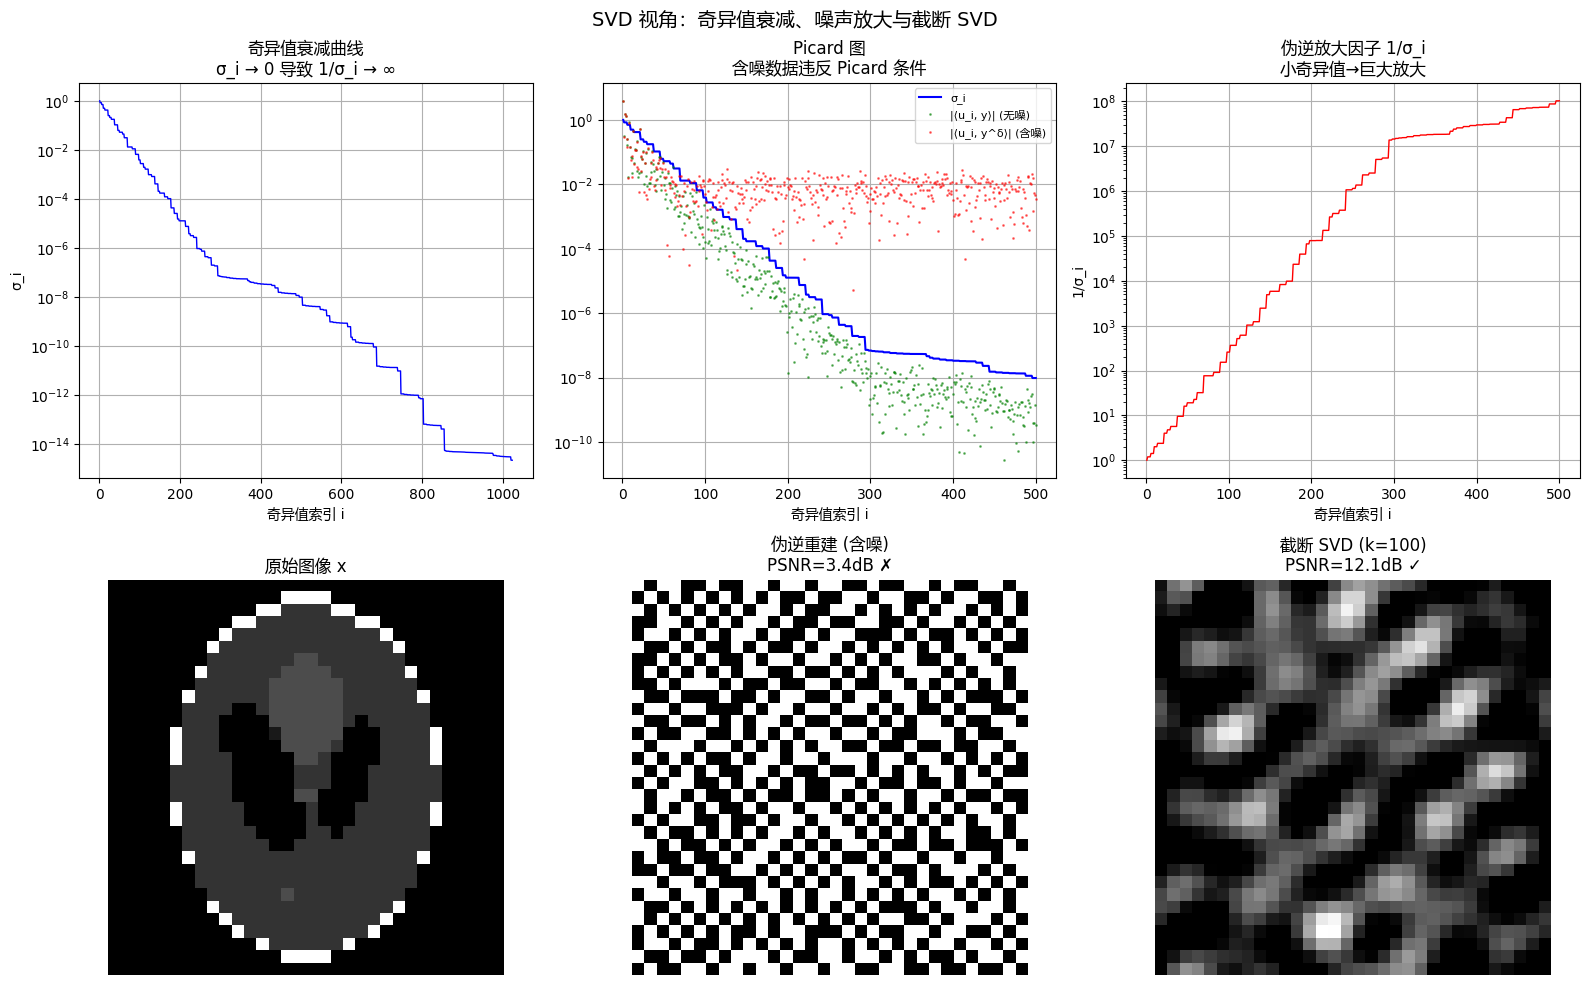

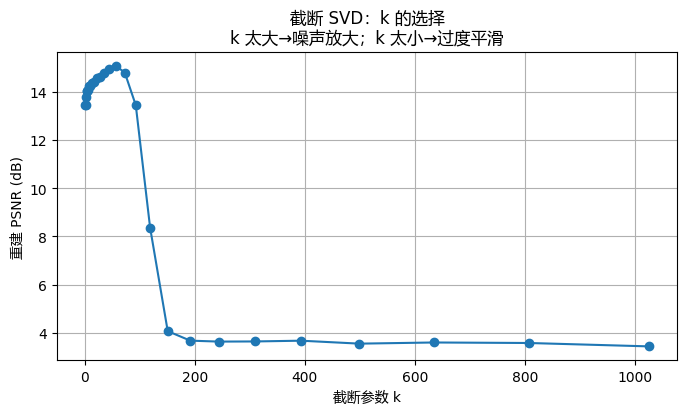

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.data import shepp_logan_phantom
from skimage.transform import resize

# ====== 解决中文乱码的核心代码 ======
plt.rcParams['font.family'] = ['DejaVu Sans', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False  # 解决负号
# ========================================================

np.random.seed(42)

# ---- 1. 构造小尺寸模糊算子的显式矩阵 ----
# 使用小尺寸以使 SVD 计算可行
n = 32
phantom = resize(shepp_logan_phantom(), (n, n), order=0, preserve_range=True, anti_aliasing=False)
x = phantom / phantom.max()
x_vec = x.ravel()  # 向量化
N = n * n

# 构造模糊矩阵 A（通过逐列应用模糊算子）
def gaussian_psf(size, sigma):
    ax = np.concatenate((np.arange(0, size // 2), np.arange(-size // 2, 0)))
    xx, yy = np.meshgrid(ax, ax)
    h = np.exp(-(xx ** 2 + yy ** 2) / (2 * sigma ** 2))
    return h / h.sum()

h = gaussian_psf(n, sigma=3.0)
H_fft = np.fft.fft2(h)

# 逐列构建 A 矩阵（小尺寸可行）
A = np.zeros((N, N))
for j in range(N):
    e_j = np.zeros(N)
    e_j[j] = 1.0
    Ae_j = np.real(np.fft.ifft2(H_fft * np.fft.fft2(e_j.reshape(n, n)))).ravel()
    A[:, j] = Ae_j

# ---- 2. SVD 分解 ----
print("计算 SVD（矩阵大小 {}x{}）...".format(N, N))
U, sigma, Vt = np.linalg.svd(A, full_matrices=False)

# ---- 3. 生成含噪观测 ----
y_clean = A @ x_vec
noise_sigma = 0.01
y_noisy = y_clean + noise_sigma * np.random.randn(N)

# ---- 4. 伪逆解 vs 截断 SVD 解 ----
# 伪逆解（使用所有奇异值）
x_pinv = Vt.T @ (np.diag(1.0 / sigma) @ (U.T @ y_noisy))

# 截断 SVD 解（保留前 k 个奇异值）
truncation_levels = [50, 100, 200, 500]
x_trunc = {}
for k in truncation_levels:
    k = min(k, len(sigma))
    x_trunc[k] = Vt[:k, :].T @ (np.diag(1.0 / sigma[:k]) @ (U[:, :k].T @ y_noisy))

# ---- 5. Picard 图 ----
coeffs_clean = np.abs(U.T @ y_clean)
coeffs_noisy = np.abs(U.T @ y_noisy)

# ---- 6. 可视化 ----
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# (a) 奇异值衰减
axes[0, 0].semilogy(np.arange(1, len(sigma) + 1), sigma, 'b-', linewidth=1)
axes[0, 0].set_xlabel('奇异值索引 i')
axes[0, 0].set_ylabel('σ_i')
axes[0, 0].set_title('奇异值衰减曲线\nσ_i → 0 导致 1/σ_i → ∞')
axes[0, 0].grid(True)

# (b) Picard 图
i_range = np.arange(1, min(500, len(sigma)) + 1)
axes[0, 1].semilogy(i_range, sigma[:len(i_range)], 'b-', label='σ_i')
axes[0, 1].semilogy(i_range, coeffs_clean[:len(i_range)], 'g.', markersize=2, alpha=0.5, label='|⟨u_i, y⟩| (无噪)')
axes[0, 1].semilogy(i_range, coeffs_noisy[:len(i_range)], 'r.', markersize=2, alpha=0.5, label='|⟨u_i, y^δ⟩| (含噪)')
axes[0, 1].set_xlabel('奇异值索引 i')
axes[0, 1].set_title('Picard 图\n含噪数据违反 Picard 条件')
axes[0, 1].legend(fontsize=8)
axes[0, 1].grid(True)

# (c) 1/σ_i 的爆炸性增长
axes[0, 2].semilogy(i_range, 1.0 / sigma[:len(i_range)], 'r-', linewidth=1)
axes[0, 2].set_xlabel('奇异值索引 i')
axes[0, 2].set_ylabel('1/σ_i')
axes[0, 2].set_title('伪逆放大因子 1/σ_i\n小奇异值→巨大放大')
axes[0, 2].grid(True)

# (d) 原始图像
axes[1, 0].imshow(x, cmap='gray')
axes[1, 0].set_title('原始图像 x')
axes[1, 0].axis('off')

# (e) 伪逆重建（含噪数据）
x_pinv_img = np.clip(x_pinv.reshape(n, n), 0, 1)
from skimage.metrics import peak_signal_noise_ratio
psnr_pinv = peak_signal_noise_ratio(x, x_pinv_img)
axes[1, 1].imshow(x_pinv_img, cmap='gray')
axes[1, 1].set_title(f'伪逆重建 (含噪)\nPSNR={psnr_pinv:.1f}dB ✗')
axes[1, 1].axis('off')

# (f) 截断 SVD 重建
best_k = truncation_levels[1]  # 展示 k=100 的结果
x_trunc_img = np.clip(x_trunc[best_k].reshape(n, n), 0, 1)
psnr_trunc = peak_signal_noise_ratio(x, x_trunc_img)
axes[1, 2].imshow(x_trunc_img, cmap='gray')
axes[1, 2].set_title(f'截断 SVD (k={best_k})\nPSNR={psnr_trunc:.1f}dB ✓')
axes[1, 2].axis('off')

plt.suptitle('SVD 视角：奇异值衰减、噪声放大与截断 SVD', fontsize=14)
plt.tight_layout()
plt.savefig('实验1_7_SVD视角.png', dpi=150, bbox_inches='tight')
plt.show()

# ---- 7. 截断参数 k 对重建质量的影响 ----
k_list = np.unique(np.logspace(0, np.log10(len(sigma)), 30).astype(int))
psnr_k = []
for k in k_list:
    x_k = Vt[:k, :].T @ (np.diag(1.0 / sigma[:k]) @ (U[:, :k].T @ y_noisy))
    psnr_k.append(peak_signal_noise_ratio(x, np.clip(x_k.reshape(n, n), 0, 1)))

plt.figure(figsize=(8, 4))
plt.plot(k_list, psnr_k, 'o-')
plt.xlabel('截断参数 k')
plt.ylabel('重建 PSNR (dB)')
plt.title('截断 SVD：k 的选择\nk 太大→噪声放大；k 太小→过度平滑')
plt.grid(True)
plt.savefig('实验1_7_截断SVD参数.png', dpi=150, bbox_inches='tight')
plt.show()